In [10]:
import numpy as np
import pandas as pd 
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.utils.data as tdata
from sklearn.preprocessing import StandardScaler
from datetime import date, datetime, timedelta 
from dateutil import relativedelta
from timeit import default_timer as timer

import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings("ignore")

from preprocess_data import * 
from model_training import *
from test_models import *

In [2]:
import sys
import os 
pjrt = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(pjrt)

from src.load_data import load_stocks
from src.xgboost_model.xgboost_etl import *

In [3]:
# start with a basic model
start_date = "2015-11-01"
end_date = datetime.today().strftime("%Y-%m-%d")
cutoff = datetime(2025, 9, 1, 0, 0, 0)

df = load_stocks(["AAPL"], start_date, end_date, use_polars=False)
# df_full = prep_columns(df, "close").to_pandas().dropna()

feat_cols = [c for c in df.columns if c not in ["date", "ticker", "close"]]

# df_full.head()
df.head()

[*********************100%***********************]  1 of 1 completed


Field,date,ticker,close,high,low,open,volume
0,2015-11-02,AAPL,27.205872,27.246283,26.853394,27.120559,128813200
1,2015-11-03,AAPL,27.517937,27.724484,27.098106,27.118313,182076000
2,2015-11-04,AAPL,27.389969,27.798573,27.304656,27.643662,179544400
3,2015-11-05,AAPL,27.263706,27.662787,27.096860,27.473392,158210800
4,2015-11-06,AAPL,27.295273,27.464375,27.196068,27.306547,132169200


In [4]:
# for some feature engineering, these guys (https://arxiv.org/html/2501.17366v1#S3) used:
# 3.1 Data Sources and Features

# The dataset used in this study encompasses daily values for the S&P 500 (SPX) over the period of October 2013 to September 2024. The historical SPX data include:

# • 50 and 200-day Moving Averages (MOV_AVG_50/200D)
# • 14-day Relative Strength Index (RSI_14D)
# • Open and Closing Prices (PX_OPEN/CLOSE)
# • High and Low Prices (PX_HIGH/LOW)
# • Daily Price High-Low Difference (PX_HIGH_LOW_DIFFERENCE)
# • Daily Volume (PX_VOLUME)
# • 30-day Volatility (VOLATILITY_30D)
# • Beta (BETA_ADJ_OVERRIDABLE)

In [5]:
# even worth doing lstm
lookback = 14
train_prop = 0.7

values = df[feat_cols + ["close"]].values.astype("float32")

X_list, y_list = [], []
for i in range(lookback, len(values)):
    X_list.append(values[i-lookback:i, :-1])
    y_list.append(values[i, -1])

y_all = np.array(y_list)
n_train = int(len(y_all) * train_prop)

y_train_np = y_all[:n_train]
y_test_np = y_all[n_train:]

y_pred_naive = np.roll(y_all, 1)[n_train:]
y_true = y_test_np
naive_rmse = np.sqrt(np.mean((y_pred_naive - y_true) ** 2))
print(f"naive 1-step RMSE (y_t = y_(t-1)): {naive_rmse:.5f}")

naive 1-step RMSE (y_t = y_(t-1)): 3.25466


In [9]:
df_scaled, scaler = scale_features(df, feat_cols)
X_train, X_test, y_train, y_test = make_lstm_sequences(
    df_scaled, feat_cols, "close", lookback=14
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1763, 14, 4]) torch.Size([1763]) torch.float32 torch.float32
torch.Size([756, 14, 4]) torch.Size([756]) torch.float32 torch.float32


# experiment 1

models trained with base hyperparameters
- 1 layer
- 0.0 dropout
- 14 day lookback window for sequences
- 1e-3 LR, 1e-3 weight decay
- 50 epochs

In [ ]:
input_size = X_train.shape[-1]

model1 = LSTMStockForecaster(input_units=input_size)
model2 = LSTMBiDirStockForecaster(input_units=input_size)
model3 = AttentiveLSTMStockForecaster(input_units=input_size)
model4 = GRUStockForecaster(input_units=input_size)

In [ ]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 50

In [ ]:
res1 = train_model(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 63.52073
 test_loss: 106.96438
 run time: 0.3361201250227168


epoch: 1
 train loss: 8.56705
 test_loss: 37.70539
 run time: 0.2795380839961581


epoch: 2
 train loss: 3.70946
 test_loss: 30.74236
 run time: 0.27831208301358856


epoch: 3
 train loss: 3.33811
 test_loss: 31.08025
 run time: 0.30036104199825786


epoch: 4
 train loss: 3.04456
 test_loss: 29.41344
 run time: 0.3207343749818392


epoch: 5
 train loss: 2.98375
 test_loss: 26.44976
 run time: 0.31389095800113864


epoch: 6
 train loss: 2.70143
 test_loss: 24.41213
 run time: 0.2863207919872366


epoch: 7
 train loss: 2.53755
 test_loss: 25.11748
 run time: 0.282464957999764


epoch: 8
 train loss: 2.54883
 test_loss: 22.17854
 run time: 0.28175454199663363


epoch: 9
 train loss: 2.34533
 test_loss: 21.65868
 run time: 0.2812949579965789


epoch: 10
 train loss: 2.24048
 test_loss: 19.22816
 run time: 0.281821749988012


epoch: 11
 train loss: 2.24156
 test_loss: 19.74099
 run time: 0.27962062502047047

In [ ]:
res2 = train_model(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 77.03755
 test_loss: 166.03233
 run time: 0.5122443329892121


epoch: 1
 train loss: 54.73867
 test_loss: 135.27411
 run time: 0.6639470829977654


epoch: 2
 train loss: 37.52300
 test_loss: 110.25183
 run time: 0.5825469590199646


epoch: 3
 train loss: 24.05602
 test_loss: 87.56287
 run time: 0.5586625419964548


epoch: 4
 train loss: 14.08245
 test_loss: 69.46770
 run time: 0.4931236669945065


epoch: 5
 train loss: 8.36287
 test_loss: 56.85645
 run time: 0.49224416600191034


epoch: 6
 train loss: 5.23894
 test_loss: 48.92175
 run time: 0.5046547920210287


epoch: 7
 train loss: 4.16209
 test_loss: 44.00217
 run time: 0.49697579198982567


epoch: 8
 train loss: 3.61132
 test_loss: 40.74353
 run time: 0.4995105000270996


epoch: 9
 train loss: 3.22897
 test_loss: 39.65050
 run time: 0.49763108300976455


epoch: 10
 train loss: 2.91980
 test_loss: 37.46583
 run time: 0.49738700001034886


epoch: 11
 train loss: 2.85410
 test_loss: 37.21244
 run time: 0.494374790

In [ ]:
res3 = train_model(
    model=model3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.38621
 test_loss: 178.86659
 run time: 0.3527864999778103


epoch: 1
 train loss: 65.95797
 test_loss: 164.80551
 run time: 0.42383970800437964


epoch: 2
 train loss: 57.41138
 test_loss: 152.26959
 run time: 0.3465778339887038


epoch: 3
 train loss: 49.28457
 test_loss: 139.51143
 run time: 0.32625462498981506


epoch: 4
 train loss: 42.16616
 test_loss: 127.03104
 run time: 0.3328958330093883


epoch: 5
 train loss: 35.35201
 test_loss: 114.69250
 run time: 0.3278272079769522


epoch: 6
 train loss: 28.61659
 test_loss: 102.55138
 run time: 0.32873191600083373


epoch: 7
 train loss: 22.61404
 test_loss: 90.46117
 run time: 0.32397820899495855


epoch: 8
 train loss: 16.88721
 test_loss: 79.39939
 run time: 0.3224280840076972


epoch: 9
 train loss: 12.62173
 test_loss: 70.19234
 run time: 0.3250253339938354


epoch: 10
 train loss: 9.74165
 test_loss: 62.83788
 run time: 0.36202658398542553


epoch: 11
 train loss: 7.74888
 test_loss: 56.73158
 run time: 0

In [ ]:
res4 = train_model(
    model=model4,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.89896
 test_loss: 179.53224
 run time: 0.2742349590116646


epoch: 1
 train loss: 66.97225
 test_loss: 165.49249
 run time: 0.2640102910227142


epoch: 2
 train loss: 58.12846
 test_loss: 153.92319
 run time: 0.29275445800158195


epoch: 3
 train loss: 50.88015
 test_loss: 141.08875
 run time: 0.31294012497528456


epoch: 4
 train loss: 42.98246
 test_loss: 128.51584
 run time: 0.25712012499570847


epoch: 5
 train loss: 36.25472
 test_loss: 115.96185
 run time: 0.25932066698442213


epoch: 6
 train loss: 29.15763
 test_loss: 103.67567
 run time: 0.25682520799455233


epoch: 7
 train loss: 22.81151
 test_loss: 91.69340
 run time: 0.25703683399478905


epoch: 8
 train loss: 17.37475
 test_loss: 80.30750
 run time: 0.25629429100081325


epoch: 9
 train loss: 12.88996
 test_loss: 70.28966
 run time: 0.26482045801822096


epoch: 10
 train loss: 9.23608
 test_loss: 62.52280
 run time: 0.2677598330192268


epoch: 11
 train loss: 6.96064
 test_loss: 56.00837
 run time

In [6]:
def make_df_from_res(res):
    return pd.DataFrame(
    {
        "epoch": list(range(len(res["train_loss"]))),
        "train_loss": [t.item() for t in res["train_loss"]],
        "test_loss": [t.item() for t in res["test_loss"]]
    }
)

In [25]:
df_res1 = make_df_from_res(res1)
df_res2 = make_df_from_res(res2)
df_res3 = make_df_from_res(res3)
df_res4 = make_df_from_res(res4)

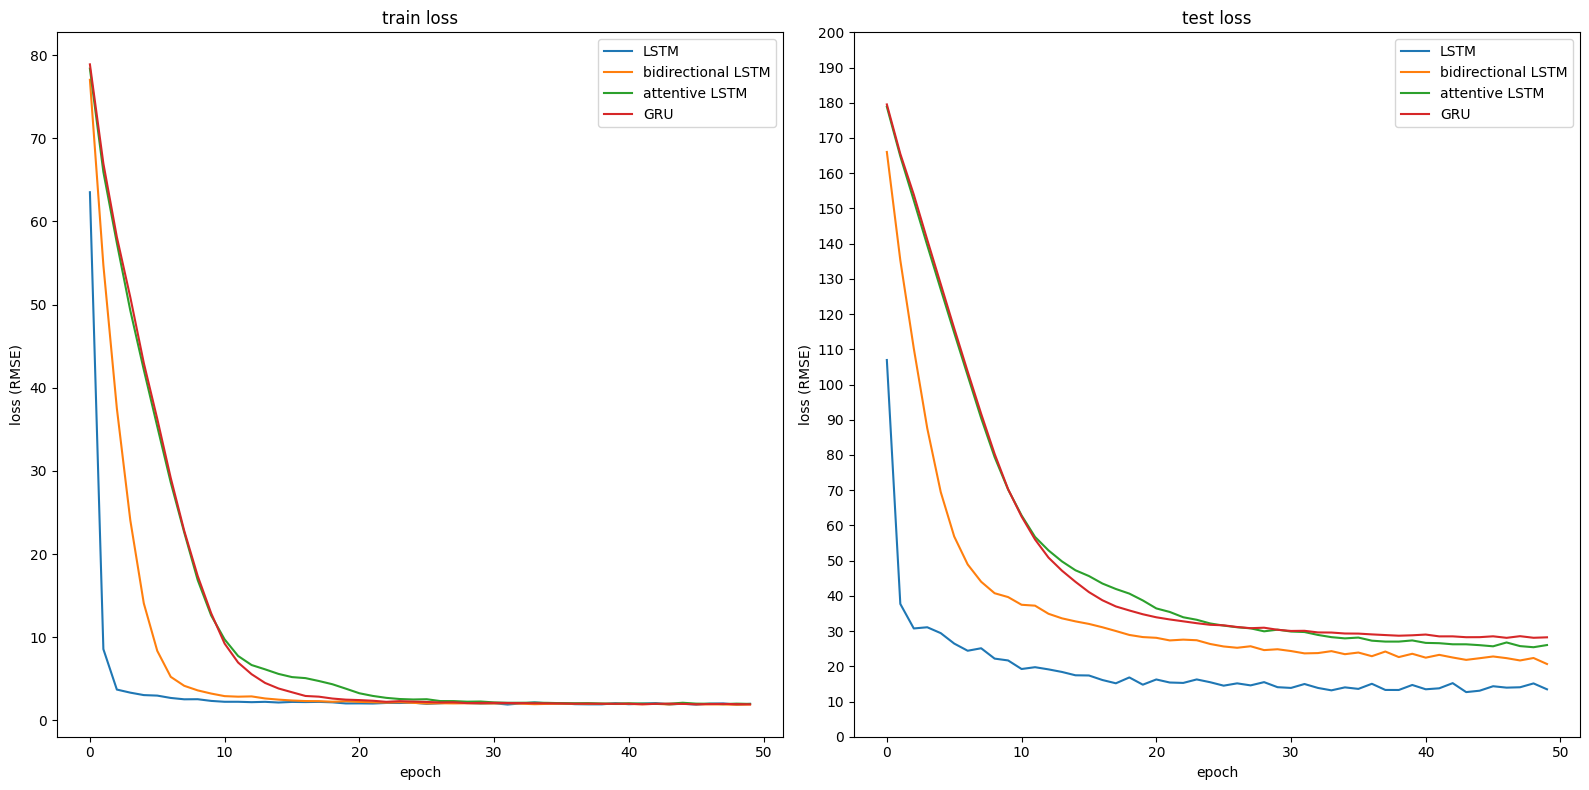

In [ ]:
plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1["epoch"], df_res1["train_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3["epoch"], df_res3["train_loss"], label="attentive LSTM");
plt.plot(df_res4["epoch"], df_res4["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1["epoch"], df_res1["test_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3["epoch"], df_res3["test_loss"], label="attentive LSTM");
plt.plot(df_res4["epoch"], df_res4["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();

# experiment 1b
similar to experiment 1, but this time using the `delta` label option...

In [41]:
df_scaled, scaler = scale_features(df, feat_cols)
X_train, X_test, y_train, y_test = make_lstm_sequences(
    df_scaled, feat_cols, "close", lookback=14, use_delta=True
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1762, 14, 4]) torch.Size([1762]) torch.float32 torch.float32
torch.Size([756, 14, 4]) torch.Size([756]) torch.float32 torch.float32


In [42]:
input_size = X_train.shape[-1]

model1 = LSTMStockForecaster(input_units=input_size)
model2 = LSTMBiDirStockForecaster(input_units=input_size)
model3 = AttentiveLSTMStockForecaster(input_units=input_size)
model4 = GRUStockForecaster(input_units=input_size)

In [43]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 25

In [44]:
res1b = train_model(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.62182
 test_loss: 2.86542
 run time: 0.34031183397746645


epoch: 1
 train loss: 1.63075
 test_loss: 2.85676
 run time: 0.30082441700506024


epoch: 2
 train loss: 1.60276
 test_loss: 2.85551
 run time: 0.3348855419899337


epoch: 3
 train loss: 1.60451
 test_loss: 2.85534
 run time: 0.28784862501197495


epoch: 4
 train loss: 1.60135
 test_loss: 2.85821
 run time: 0.2984012499800883


epoch: 5
 train loss: 1.59540
 test_loss: 2.86034
 run time: 0.28617383298114873


epoch: 6
 train loss: 1.61849
 test_loss: 2.86405
 run time: 0.3336602920026053


epoch: 7
 train loss: 1.61966
 test_loss: 2.85909
 run time: 0.33507708300021477


epoch: 8
 train loss: 1.61908
 test_loss: 2.86442
 run time: 0.2916794999910053


epoch: 9
 train loss: 1.60621
 test_loss: 2.86822
 run time: 0.2901004170125816


epoch: 10
 train loss: 1.60218
 test_loss: 2.86506
 run time: 0.28955920902080834


epoch: 11
 train loss: 1.61597
 test_loss: 2.86938
 run time: 0.28730491700116545


epoch: 

In [45]:
res2b = train_model(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.60753
 test_loss: 2.86709
 run time: 0.5071357499982696


epoch: 1
 train loss: 1.61785
 test_loss: 2.85842
 run time: 0.4949922499945387


epoch: 2
 train loss: 1.60864
 test_loss: 2.85974
 run time: 0.5194235419912729


epoch: 3
 train loss: 1.60970
 test_loss: 2.86172
 run time: 0.6053761669900268


epoch: 4
 train loss: 1.60239
 test_loss: 2.86432
 run time: 0.5043240419763606


epoch: 5
 train loss: 1.59147
 test_loss: 2.85954
 run time: 0.4917320839886088


epoch: 6
 train loss: 1.62128
 test_loss: 2.86390
 run time: 0.5228197920077946


epoch: 7
 train loss: 1.59959
 test_loss: 2.87123
 run time: 0.5016720410203561


epoch: 8
 train loss: 1.61450
 test_loss: 2.86439
 run time: 0.5363494999764953


epoch: 9
 train loss: 1.62674
 test_loss: 2.87429
 run time: 0.5667053330107592


epoch: 10
 train loss: 1.58982
 test_loss: 2.87070
 run time: 0.49471745899063535


epoch: 11
 train loss: 1.62079
 test_loss: 2.87504
 run time: 0.54648650001036


epoch: 12
 trai

In [46]:
res3b = train_model(
    model=model3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.60079
 test_loss: 2.86573
 run time: 0.37134870802401565


epoch: 1
 train loss: 1.62630
 test_loss: 2.86413
 run time: 0.3235949999943841


epoch: 2
 train loss: 1.60269
 test_loss: 2.85596
 run time: 0.32353141700150445


epoch: 3
 train loss: 1.61524
 test_loss: 2.86266
 run time: 0.3210278339975048


epoch: 4
 train loss: 1.59999
 test_loss: 2.86202
 run time: 0.37347012502141297


epoch: 5
 train loss: 1.62695
 test_loss: 2.86081
 run time: 0.4788550419907551


epoch: 6
 train loss: 1.62114
 test_loss: 2.86786
 run time: 0.39078641700325534


epoch: 7
 train loss: 1.61500
 test_loss: 2.85865
 run time: 0.42948829199303873


epoch: 8
 train loss: 1.61625
 test_loss: 2.86481
 run time: 0.34885712497634813


epoch: 9
 train loss: 1.61461
 test_loss: 2.87241
 run time: 0.4057810420054011


epoch: 10
 train loss: 1.62069
 test_loss: 2.87000
 run time: 0.33822737500304356


epoch: 11
 train loss: 1.60123
 test_loss: 2.88094
 run time: 0.3367058749718126


epoch: 

In [47]:
res4b = train_model(
    model=model4,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.60474
 test_loss: 2.85856
 run time: 0.30840454198187217


epoch: 1
 train loss: 1.61373
 test_loss: 2.86892
 run time: 0.28191970800980926


epoch: 2
 train loss: 1.63299
 test_loss: 2.85534
 run time: 0.26790762500604615


epoch: 3
 train loss: 1.60916
 test_loss: 2.85829
 run time: 0.2595919579907786


epoch: 4
 train loss: 1.63394
 test_loss: 2.85917
 run time: 0.2775477499817498


epoch: 5
 train loss: 1.61483
 test_loss: 2.85516
 run time: 0.28748029202688485


epoch: 6
 train loss: 1.60906
 test_loss: 2.85567
 run time: 0.2720227919926401


epoch: 7
 train loss: 1.61349
 test_loss: 2.85986
 run time: 0.2615511250041891


epoch: 8
 train loss: 1.63097
 test_loss: 2.85661
 run time: 0.25892574997851625


epoch: 9
 train loss: 1.61236
 test_loss: 2.85758
 run time: 0.25913262501126155


epoch: 10
 train loss: 1.61989
 test_loss: 2.85756
 run time: 0.2600422080140561


epoch: 11
 train loss: 1.62311
 test_loss: 2.85640
 run time: 0.2594715839950368


epoch: 1

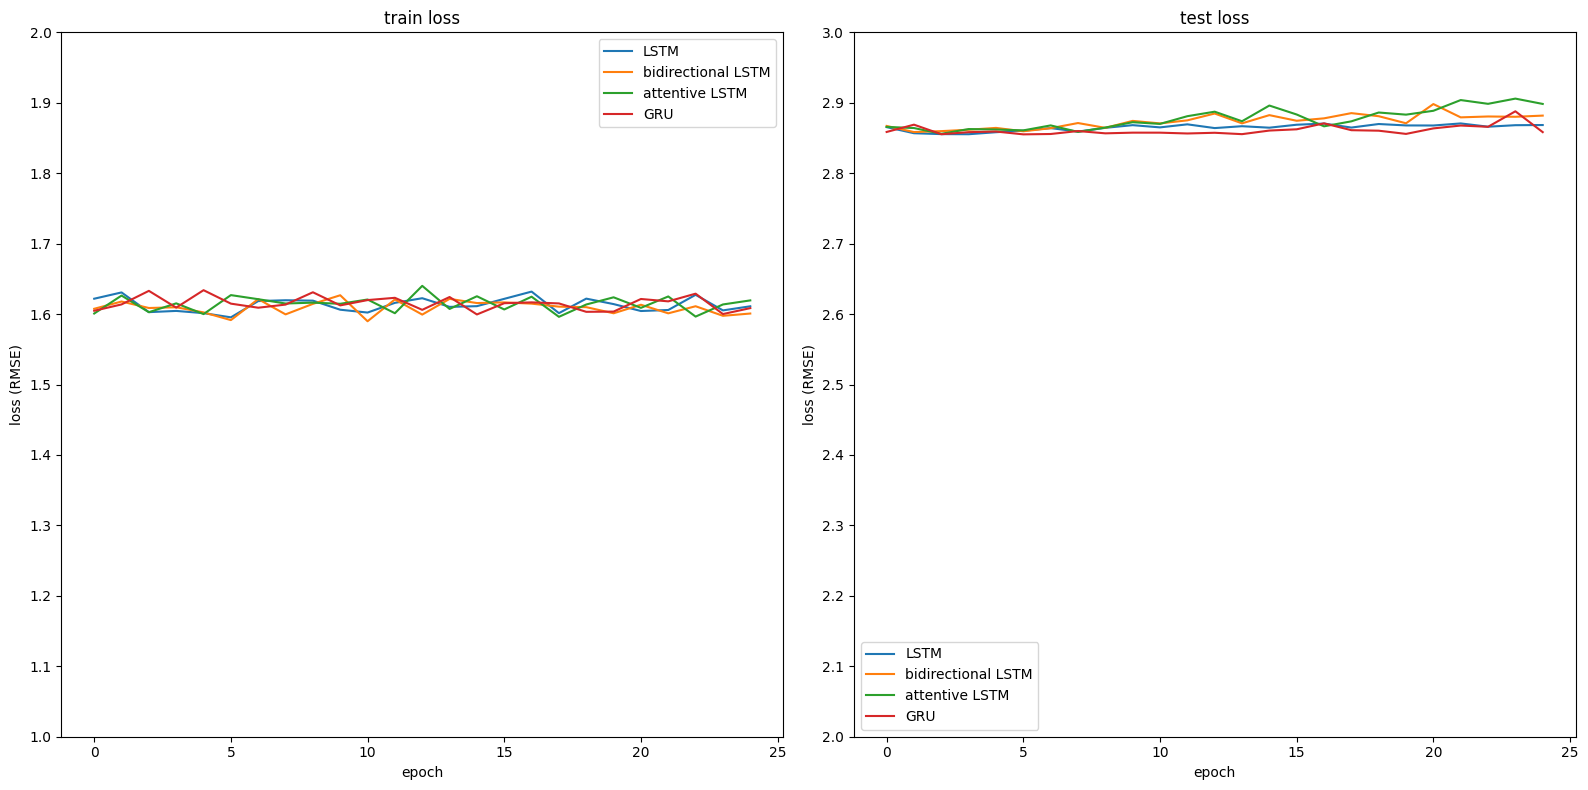

In [52]:
df_res1b = make_df_from_res(res1b)
df_res2b = make_df_from_res(res2b)
df_res3b = make_df_from_res(res3b)
df_res4b = make_df_from_res(res4b)

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1b["epoch"], df_res1b["train_loss"], label="LSTM");
plt.plot(df_res2b["epoch"], df_res2b["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3b["epoch"], df_res3b["train_loss"], label="attentive LSTM");
plt.plot(df_res4b["epoch"], df_res4b["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(1.0, 2.1, 0.1));
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1b["epoch"], df_res1b["test_loss"], label="LSTM");
plt.plot(df_res2b["epoch"], df_res2b["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3b["epoch"], df_res3b["test_loss"], label="attentive LSTM");
plt.plot(df_res4b["epoch"], df_res4b["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(2.0, 3.1, 0.1));
plt.title("test loss");


plt.tight_layout();

# experiment 2
- updating `num_layers = 2` and `dropout = 0.3`

In [36]:
input_size = X_train.shape[-1]

model1v2 = LSTMStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model2v2 = LSTMBiDirStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model3v2 = AttentiveLSTMStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model4v2 = GRUStockForecaster(input_units=input_size, num_layers=2, dropout=0.3)

In [37]:
res1v2 = train_model(
    model=model1v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 68.06859
 test_loss: 133.83585
 run time: 0.5829551249917131


epoch: 1
 train loss: 16.75265
 test_loss: 41.03820
 run time: 0.5332331669924315


epoch: 2
 train loss: 4.01510
 test_loss: 33.45517
 run time: 0.5433432910067495


epoch: 3
 train loss: 3.72563
 test_loss: 32.05269
 run time: 0.5512659169908147


epoch: 4
 train loss: 3.55503
 test_loss: 31.86129
 run time: 0.5582201670040376


epoch: 5
 train loss: 3.51905
 test_loss: 30.22644
 run time: 0.5258746670151595


epoch: 6
 train loss: 3.28614
 test_loss: 29.27867
 run time: 0.5257358750095591


epoch: 7
 train loss: 3.31590
 test_loss: 29.89479
 run time: 0.5285699579981156


epoch: 8
 train loss: 3.24957
 test_loss: 29.75231
 run time: 0.5350287920155097


epoch: 9
 train loss: 3.27787
 test_loss: 30.49650
 run time: 0.5218278329994064


epoch: 10
 train loss: 3.37528
 test_loss: 29.54161
 run time: 0.5203844579809811


epoch: 11
 train loss: 3.09995
 test_loss: 27.79624
 run time: 0.5209719580016099



In [38]:
res2v2 = train_model(
    model=model2v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 73.43818
 test_loss: 166.34349
 run time: 1.1308079170121346


epoch: 1
 train loss: 55.11823
 test_loss: 144.95692
 run time: 1.0184585000097286


epoch: 2
 train loss: 42.41323
 test_loss: 122.81301
 run time: 1.0441458749992307


epoch: 3
 train loss: 31.04139
 test_loss: 101.31363
 run time: 1.101381833985215


epoch: 4
 train loss: 19.69543
 test_loss: 81.11139
 run time: 1.0850076249917038


epoch: 5
 train loss: 11.69815
 test_loss: 64.79296
 run time: 1.1743863339943346


epoch: 6
 train loss: 7.29777
 test_loss: 54.89618
 run time: 1.0938357079867274


epoch: 7
 train loss: 5.28638
 test_loss: 48.09007
 run time: 1.0625143750221469


epoch: 8
 train loss: 4.18298
 test_loss: 43.76030
 run time: 0.9983756250003353


epoch: 9
 train loss: 3.62519
 test_loss: 40.39169
 run time: 0.9900169579777867


epoch: 10
 train loss: 3.45280
 test_loss: 38.37678
 run time: 1.1773895000224002


epoch: 11
 train loss: 3.16120
 test_loss: 37.28910
 run time: 1.136542916996

In [39]:
res3v2 = train_model(
    model=model3v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.56259
 test_loss: 179.03931
 run time: 0.6309261250135023


epoch: 1
 train loss: 66.52731
 test_loss: 165.15234
 run time: 0.5664540830184706


epoch: 2
 train loss: 57.96343
 test_loss: 152.53473
 run time: 0.558537749981042


epoch: 3
 train loss: 49.48162
 test_loss: 139.93372
 run time: 0.5596709999954328


epoch: 4
 train loss: 42.69123
 test_loss: 127.32158
 run time: 0.5594134159910027


epoch: 5
 train loss: 35.12530
 test_loss: 115.28000
 run time: 0.6024511250143405


epoch: 6
 train loss: 28.90018
 test_loss: 103.24181
 run time: 0.5944624580151867


epoch: 7
 train loss: 22.83001
 test_loss: 91.41109
 run time: 0.561655833007535


epoch: 8
 train loss: 17.22437
 test_loss: 79.92579
 run time: 0.5662200420047157


epoch: 9
 train loss: 12.63764
 test_loss: 70.44099
 run time: 0.5687813329859637


epoch: 10
 train loss: 9.43100
 test_loss: 62.31460
 run time: 0.5735499580041505


epoch: 11
 train loss: 6.78433
 test_loss: 55.92436
 run time: 0.570519

In [40]:
res4v2 = train_model(
    model=model4v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.20359
 test_loss: 179.19598
 run time: 0.580916208011331


epoch: 1
 train loss: 66.58518
 test_loss: 165.43837
 run time: 0.4973740419954993


epoch: 2
 train loss: 57.71192
 test_loss: 153.53957
 run time: 0.5137881249829661


epoch: 3
 train loss: 50.07803
 test_loss: 140.86636
 run time: 0.5024007080064621


epoch: 4
 train loss: 43.21646
 test_loss: 128.36989
 run time: 0.505556375021115


epoch: 5
 train loss: 35.89096
 test_loss: 115.93118
 run time: 0.506846875010524


epoch: 6
 train loss: 29.39151
 test_loss: 103.71674
 run time: 0.5456507919880096


epoch: 7
 train loss: 23.02497
 test_loss: 91.59026
 run time: 0.5336168750072829


epoch: 8
 train loss: 17.13204
 test_loss: 80.38482
 run time: 0.5632191670010798


epoch: 9
 train loss: 12.58185
 test_loss: 70.89285
 run time: 0.5047794170095585


epoch: 10
 train loss: 9.20103
 test_loss: 62.49177
 run time: 0.5016721670108382


epoch: 11
 train loss: 6.65488
 test_loss: 56.04161
 run time: 0.6064621

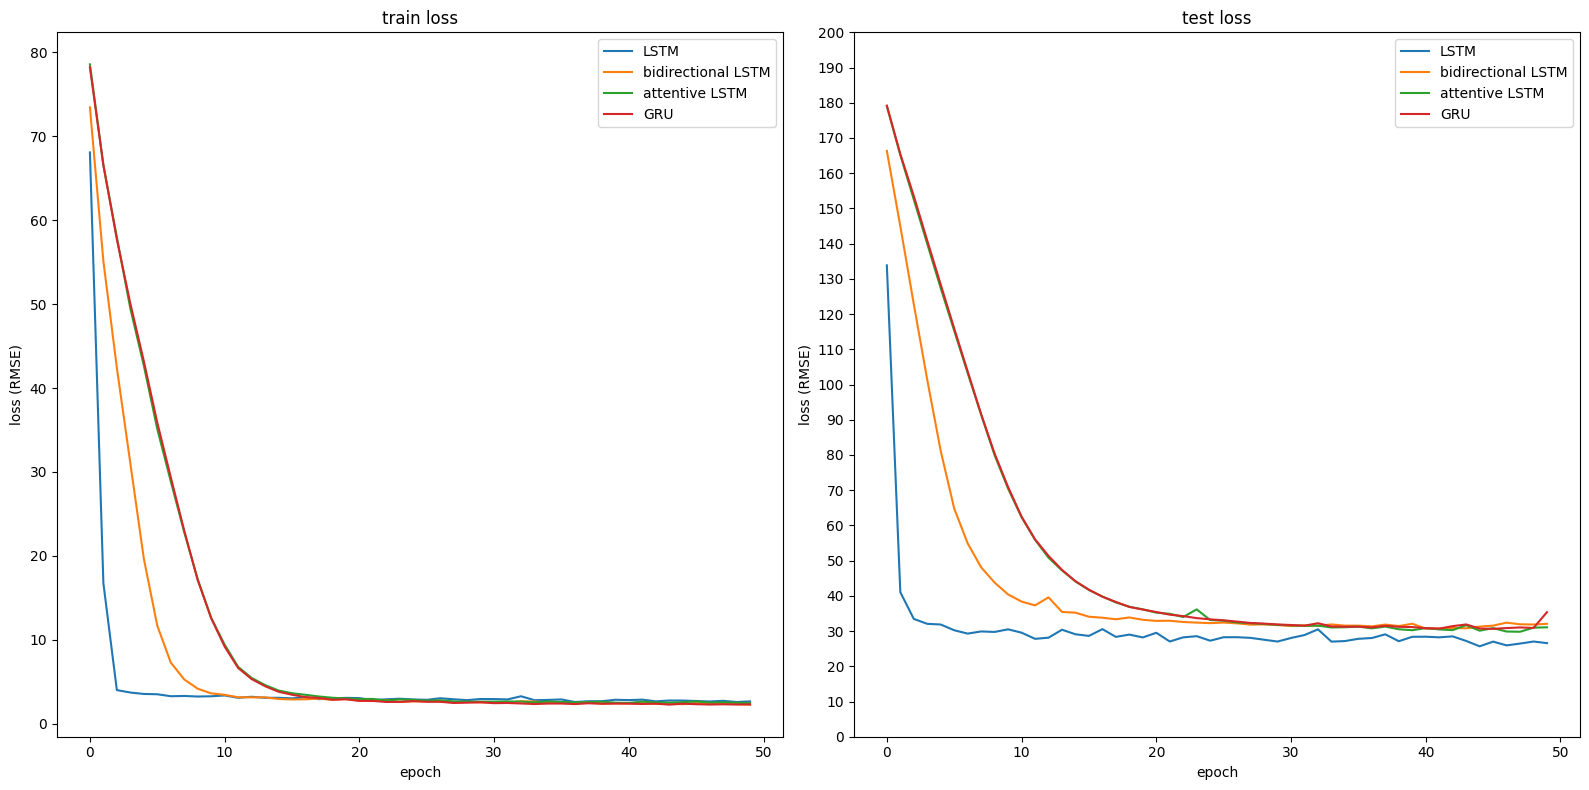

In [41]:
df_res1v2 = make_df_from_res(res1v2)
df_res2v2 = make_df_from_res(res2v2)
df_res3v2 = make_df_from_res(res3v2)
df_res4v2 = make_df_from_res(res4v2)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1v2["epoch"], df_res1v2["train_loss"], label="LSTM");
plt.plot(df_res2v2["epoch"], df_res2v2["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3v2["epoch"], df_res3v2["train_loss"], label="attentive LSTM");
plt.plot(df_res4v2["epoch"], df_res4v2["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1v2["epoch"], df_res1v2["test_loss"], label="LSTM");
plt.plot(df_res2v2["epoch"], df_res2v2["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3v2["epoch"], df_res3v2["test_loss"], label="attentive LSTM");
plt.plot(df_res4v2["epoch"], df_res4v2["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();

# experiment 3
same approach as experiment 1, but removing all features except timeseries  
i.e., _only_ model the autoregressive structure  

also increasing lookback from 14 to 30

In [27]:
X_train, X_test, y_train, y_test = process_single_feature_data(
    df=df, label="close", train_proportion=0.7, lookback=30
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1743, 30, 1]) torch.Size([1743, 30, 1]) torch.float32 torch.float32
torch.Size([730, 30, 1]) torch.Size([730, 30, 1]) torch.float32 torch.float32


In [28]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 50

In [29]:
input_size = X_train.shape[-1]

model1v3 = LSTMStockForecaster(input_units=input_size)
model2v3 = LSTMBiDirStockForecaster(input_units=input_size)
model3v3 = AttentiveLSTMStockForecaster(input_units=input_size)
model4v3 = GRUStockForecaster(input_units=input_size)

In [30]:
res1v3 = train_model(
    model=model1v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 66.41460
 test_loss: 131.75105
 run time: 0.5997062920068856


epoch: 1
 train loss: 47.86356
 test_loss: 127.68386
 run time: 0.5037462500040419


epoch: 2
 train loss: 47.95971
 test_loss: 123.79359
 run time: 0.5021482500014827


epoch: 3
 train loss: 47.68727
 test_loss: 120.34516
 run time: 0.5324486249883194


epoch: 4
 train loss: 47.64972
 test_loss: 120.40945
 run time: 0.5328557089960668


epoch: 5
 train loss: 47.67165
 test_loss: 119.95478
 run time: 0.5096426250238437


epoch: 6
 train loss: 47.66870
 test_loss: 117.24551
 run time: 0.5183027909952216


epoch: 7
 train loss: 47.38683
 test_loss: 120.64545
 run time: 0.5101162500213832


epoch: 8
 train loss: 47.62271
 test_loss: 116.09929
 run time: 0.5075543750135694


epoch: 9
 train loss: 47.59667
 test_loss: 115.16035
 run time: 0.5043917500006501


epoch: 10
 train loss: 47.61377
 test_loss: 115.16107
 run time: 0.5043947910016868


epoch: 11
 train loss: 47.69148
 test_loss: 116.94900
 run time:

In [31]:
res2v3 = train_model(
    model=model2v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 74.50565
 test_loss: 166.51515
 run time: 1.2434954579803161


epoch: 1
 train loss: 55.26102
 test_loss: 145.61916
 run time: 1.0444275840127375


epoch: 2
 train loss: 49.68655
 test_loss: 134.40781
 run time: 0.9933758749975823


epoch: 3
 train loss: 48.15245
 test_loss: 128.98866
 run time: 0.9542779169860296


epoch: 4
 train loss: 47.89214
 test_loss: 127.73204
 run time: 0.972199667012319


epoch: 5
 train loss: 47.86696
 test_loss: 127.49097
 run time: 0.9419762500037905


epoch: 6
 train loss: 47.75284
 test_loss: 126.15099
 run time: 0.940511124994373


epoch: 7
 train loss: 47.78963
 test_loss: 124.69434
 run time: 0.9408688750118017


epoch: 8
 train loss: 47.63686
 test_loss: 123.90174
 run time: 0.9422294170071837


epoch: 9
 train loss: 47.64537
 test_loss: 122.49236
 run time: 0.9419475409958977


epoch: 10
 train loss: 47.52478
 test_loss: 121.57079
 run time: 0.9366627909766976


epoch: 11
 train loss: 47.59435
 test_loss: 120.27174
 run time: 0

In [32]:
res3v3 = train_model(
    model=model3v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.74081
 test_loss: 179.45958
 run time: 0.6392025419918355


epoch: 1
 train loss: 66.01337
 test_loss: 165.09685
 run time: 0.6247808749903925


epoch: 2
 train loss: 57.47865
 test_loss: 153.31664
 run time: 0.6531205829815008


epoch: 3
 train loss: 52.12333
 test_loss: 144.45537
 run time: 0.5944271670014132


epoch: 4
 train loss: 49.90530
 test_loss: 137.84509
 run time: 0.5803951249981765


epoch: 5
 train loss: 48.58774
 test_loss: 133.41811
 run time: 0.6150045839895029


epoch: 6
 train loss: 48.14854
 test_loss: 130.69386
 run time: 0.6151098329864908


epoch: 7
 train loss: 47.98859
 test_loss: 128.80923
 run time: 0.656809375010198


epoch: 8
 train loss: 47.81990
 test_loss: 128.08589
 run time: 0.5868880420166533


epoch: 9
 train loss: 47.75278
 test_loss: 127.44283
 run time: 0.5794563330127858


epoch: 10
 train loss: 47.86534
 test_loss: 126.99750
 run time: 0.5697434580069967


epoch: 11
 train loss: 47.70710
 test_loss: 126.02390
 run time: 

In [33]:
res4v3 = train_model(
    model=model4v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 79.30469
 test_loss: 181.00723
 run time: 0.4915390000096522


epoch: 1
 train loss: 67.16521
 test_loss: 167.41107
 run time: 0.49196462499094196


epoch: 2
 train loss: 58.73911
 test_loss: 155.76366
 run time: 0.47663608301081695


epoch: 3
 train loss: 53.16427
 test_loss: 146.31332
 run time: 0.47327045898418874


epoch: 4
 train loss: 50.24281
 test_loss: 139.34824
 run time: 0.5105012080166489


epoch: 5
 train loss: 48.77975
 test_loss: 134.58215
 run time: 0.48939970799256116


epoch: 6
 train loss: 48.26455
 test_loss: 131.24318
 run time: 0.4736251669819467


epoch: 7
 train loss: 47.88734
 test_loss: 129.36075
 run time: 0.47256404199288227


epoch: 8
 train loss: 47.95591
 test_loss: 128.06100
 run time: 0.4756663329899311


epoch: 9
 train loss: 47.88951
 test_loss: 127.64693
 run time: 0.4710196249943692


epoch: 10
 train loss: 47.90263
 test_loss: 127.09332
 run time: 0.47019366701715626


epoch: 11
 train loss: 47.90453
 test_loss: 125.86709
 run

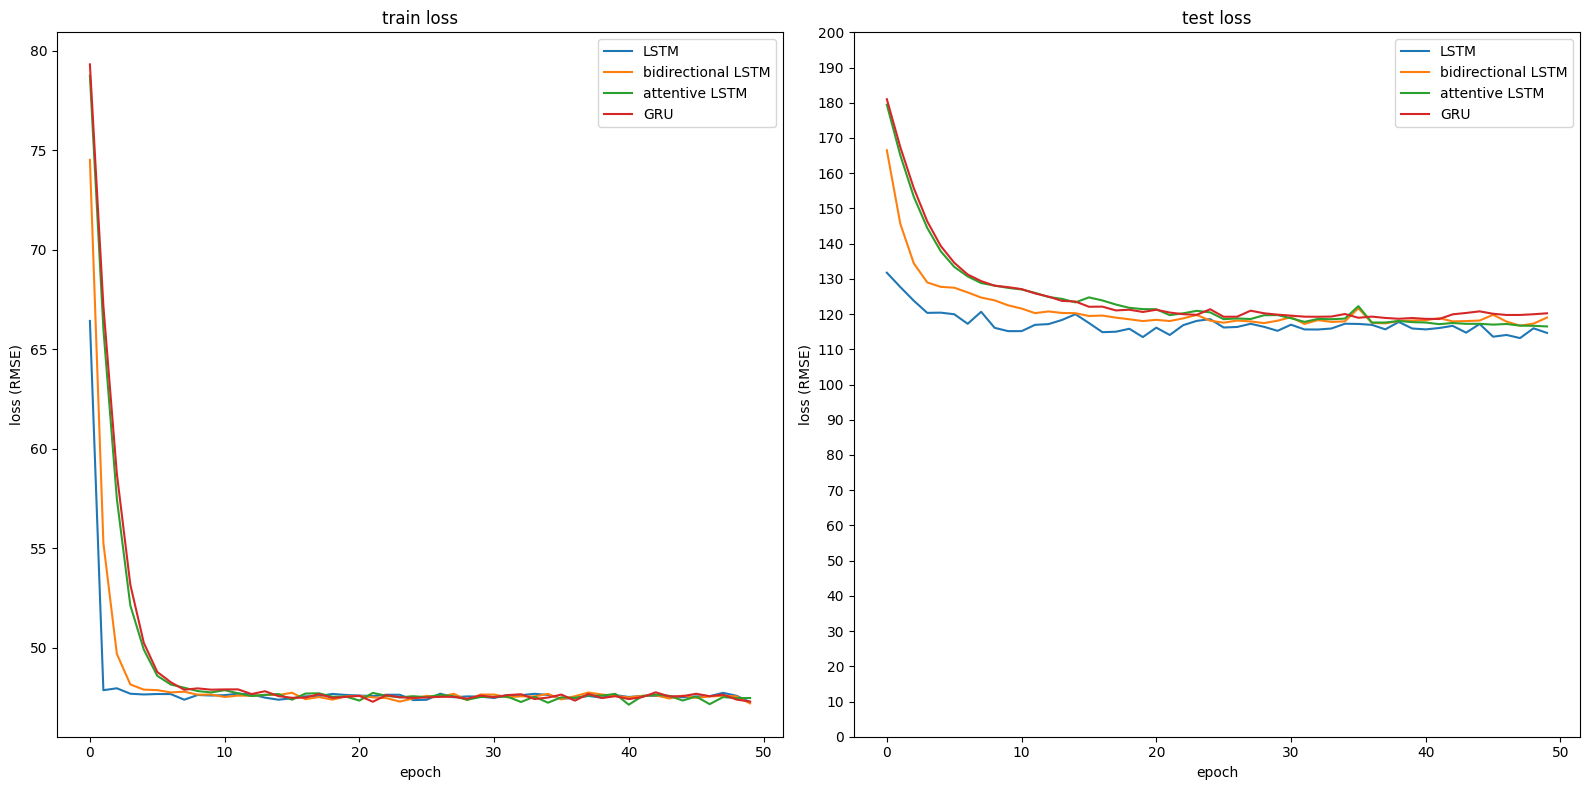

In [34]:
df_res1v3 = make_df_from_res(res1v3)
df_res2v3 = make_df_from_res(res2v3)
df_res3v3 = make_df_from_res(res3v3)
df_res4v3 = make_df_from_res(res4v3)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1v3["epoch"], df_res1v3["train_loss"], label="LSTM");
plt.plot(df_res2v3["epoch"], df_res2v3["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3v3["epoch"], df_res3v3["train_loss"], label="attentive LSTM");
plt.plot(df_res4v3["epoch"], df_res4v3["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1v3["epoch"], df_res1v3["test_loss"], label="LSTM");
plt.plot(df_res2v3["epoch"], df_res2v3["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3v3["epoch"], df_res3v3["test_loss"], label="attentive LSTM");
plt.plot(df_res4v3["epoch"], df_res4v3["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();